  E0 (1).csv: 309 rijen (2025-08-15 → 2026-03-22)
  E0 (2).csv: 380 rijen (2024-08-16 → 2025-05-25)
  E0 (3).csv: 380 rijen (2023-08-11 → 2024-05-19)
  E0 (4).csv: 380 rijen (2022-08-05 → 2023-05-28)
  E0 (5).csv: 380 rijen (2021-08-13 → 2022-05-22)
  E0 (6).csv: 380 rijen (2020-09-12 → 2021-05-23)

Totaal odds: 2209 wedstrijden
Kalman:      2608 wedstrijden
B365 gevuld: 2209
PSH gevuld:  2110

Kalman kansen berekend voor 2608 wedstrijden
Gemiddelde kansen: P(H)=0.435, P(D)=0.244, P(A)=0.321
Alle wedstrijden: 2190 wedstrijden
Na cold-start filter (>5 wedstrijden gespeeld): 1581 wedstrijden (609 uitgesloten)
Gekoppeld: 1581 wedstrijden
Periode:   2020-12-05 → 2026-03-22

  BET365  (edge ≥ 5%)
  Wedstrijden beschikbaar: 1581
  Bets geplaatst:          813
  Netto resultaat:         €60.65
  ROI:                     +7.5%
  Win rate:                34.2%

  PINNACLE  (edge ≥ 5%)
  Wedstrijden beschikbaar: 1463
  Bets geplaatst:          766
  Netto resultaat:         €77.40
  ROI:        

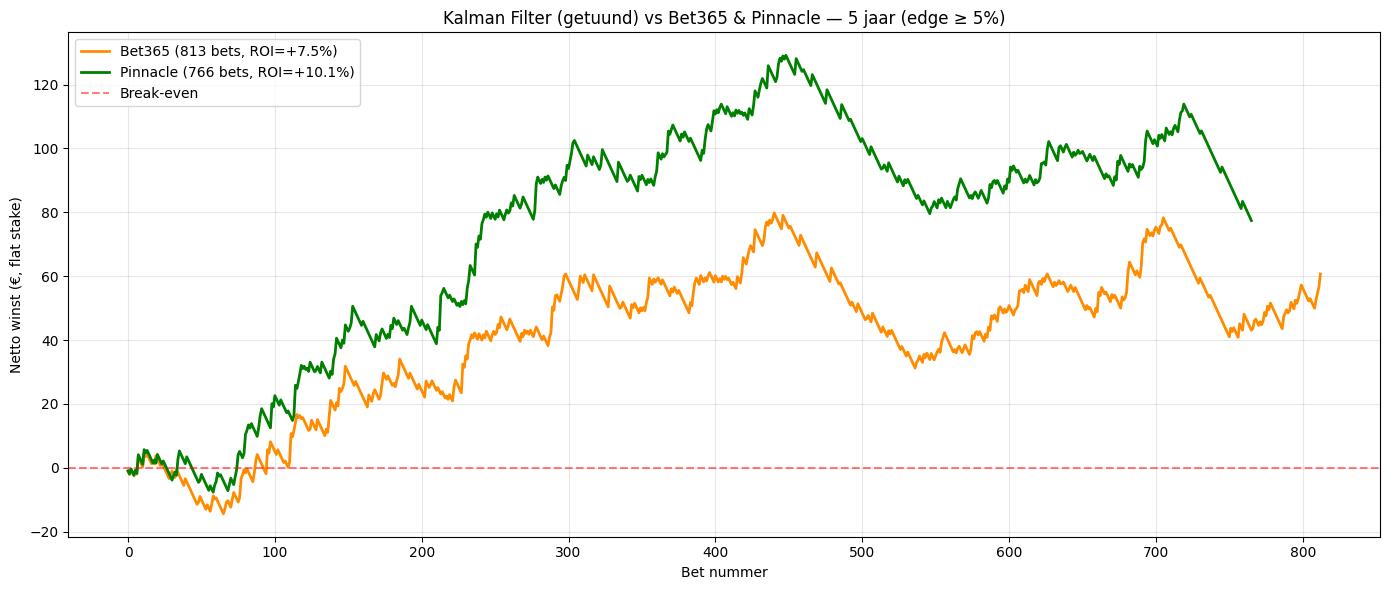


=== ROI BIJ VERSCHILLENDE DREMPELS ===
 Drempel | B365 bets  B365 ROI | Pinn bets  Pinn ROI
-------------------------------------------------------
    0.00 |      1581     +6.5% |      1463     +7.2%
    0.02 |      1314     +6.4% |      1215    +10.4%
    0.05 |       813     +7.5% |       766    +10.1%
    0.08 |       438     +8.0% |       406    +12.3%
    0.10 |       286     +3.9% |       268     +3.9%
    0.15 |        82    +31.4% |        77    +18.6%
    0.20 |        15    -16.8% |        12    -20.4%

=== ACCURACY ===
Kalman:   0.552
Bet365:   0.559
Pinnacle: 0.558

=== BRIER SCORE (lager = beter) ===
             Kalman   Bet365 Pinnacle
Thuis         0.210    0.207    0.207
Gelijk        0.175    0.176    0.176
Uit           0.193    0.190    0.190

=== RANDOM BASELINE (1000x, Bet365 odds) ===
Gemiddelde random ROI: -4.7%
95% interval:         [-12.2%, +3.0%]
Kalman B365 ROI:      +7.5%
✅ Statistisch significant op 95% niveau

Resultaten opgeslagen.

=== PRESTATIE PER K

In [21]:
"""
Kalman Betting Simulatie — Bet365 + Pinnacle (5 jaar)
======================================================
Input:
  - Kalman data/kalman_expected_goals.csv  (nieuwe versie met getuunde parameters)
  - odds raw/E0*.csv  (2020 t/m 2025)

Wijzigingen tov vorige versie:
  - Scaling factoren herberekend op basis van nieuwe Kalman predictions
    (pred home gemiddeld 1.452 vs werkelijk 1.636 → ratio 1.127)
  - Negatieve xG predictions geclipped naar minimum 0.05
  - Dixon-Coles rho aangepast
"""

import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sklearn.metrics import accuracy_score, brier_score_loss

warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\semwi\FPL-Core-Insights\data"
os.chdir(BASE_DIR)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 1 — Data laden
# ══════════════════════════════════════════════════════════════════════════════
kalman = pd.read_csv(r"Kalman data\kalman_expected_goals.csv")
kalman['date'] = pd.to_datetime(kalman['date'])

ODDS_TEAM_MAP = {
    "Man United":    "Manchester United",
    "Man City":      "Manchester City",
    "Tottenham":     "Tottenham Hotspur",
    "Newcastle":     "Newcastle United",
    "Brighton":      "Brighton & Hove Albion",
    "West Ham":      "West Ham United",
    "Leicester":     "Leicester City",
    "Ipswich":       "Ipswich Town",
    "Luton":         "Luton Town",
    "Wolves":        "Wolverhampton Wanderers",
    "Wolverhampton": "Wolverhampton Wanderers",
    "Nott'm Forest": "Nottingham Forest",
    "Leeds":         "Leeds United",
    "West Brom":     "West Bromwich Albion",
}

KALMAN_TEAM_MAP = {
    "Wolverhampton":           "Wolverhampton Wanderers",
    "Wolverhampton Wanderers": "Wolverhampton Wanderers",
}

# Laad alle odds bestanden vanaf 2020
odds_dfs = []
for path in sorted(glob.glob(os.path.join(BASE_DIR, r"odds raw\E0*.csv"))):
    df = pd.read_csv(path, encoding='latin-1')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df[df['Date'] >= '2020-08-01']
    if len(df) > 0:
        odds_dfs.append(df)
        print(f"  {os.path.basename(path)}: {len(df)} rijen "
              f"({df['Date'].min().date()} → {df['Date'].max().date()})")

odds = pd.concat(odds_dfs, ignore_index=True)
odds['HomeTeam'] = odds['HomeTeam'].replace(ODDS_TEAM_MAP)
odds['AwayTeam'] = odds['AwayTeam'].replace(ODDS_TEAM_MAP)
odds['_date'] = odds['Date'].dt.date.astype(str)

print(f"\nTotaal odds: {len(odds)} wedstrijden")
print(f"Kalman:      {len(kalman)} wedstrijden")
print(f"B365 gevuld: {odds['B365H'].notna().sum()}")
print(f"PSH gevuld:  {odds['PSH'].notna().sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 2 — Poisson kansen via Dixon-Coles
# ══════════════════════════════════════════════════════════════════════════════

# Scaling: Kalman xG predictions zijn lager dan werkelijke xG
# Herberekend op basis van nieuwe getuunde Kalman parameters:
#   pred_home gemiddeld = 1.452, werkelijk = 1.636 → ratio = 1.127
#   pred_away gemiddeld = 1.207, werkelijk = 1.360 → ratio = 1.127
SCALE_HOME = 1.1265
SCALE_AWAY = 1.1264

def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    """Correctiefactor voor lage scores (Dixon & Coles, 1997)."""
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    """
    Converteer Kalman xG voorspellingen naar win/draw/loss kansen.

    Stappen:
    1. Clip negatieve waarden (kunnen voorkomen bij zwakke teams)
    2. Schaal naar werkelijk xG niveau via empirische ratio
    3. Dixon-Coles correctie voor lage scores
    4. Sommeer over scorelijnen
    """
    # Clip negatieve xG — kunnen voorkomen door negatieve gamma states
    lambda_home = max(lambda_home, 0.05)
    lambda_away = max(lambda_away, 0.05)

    # Schaal naar werkelijk xG niveau
    lambda_home = lambda_home * SCALE_HOME
    lambda_away = lambda_away * SCALE_AWAY

    prob_home = prob_draw = prob_away = 0.0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p

    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# ══════════════════════════════════════════════════════════════════════════════
# STAP 3 — Kalman kansen berekenen
# ══════════════════════════════════════════════════════════════════════════════
kalman_valid = kalman[kalman['kalman_xg_pred_home'].notna()].copy()
kalman_valid['home_team'] = kalman_valid['home_team'].replace(KALMAN_TEAM_MAP)
kalman_valid['away_team'] = kalman_valid['away_team'].replace(KALMAN_TEAM_MAP)

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(
        row['kalman_xg_pred_home'],
        row['kalman_xg_pred_away']
    ),
    axis=1
)
kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]
kalman_valid['_date'] = kalman_valid['date'].dt.date.astype(str)

print(f"\nKalman kansen berekend voor {len(kalman_valid)} wedstrijden")
print(f"Gemiddelde kansen: P(H)={kalman_valid['kalman_prob_home'].mean():.3f}, "
      f"P(D)={kalman_valid['kalman_prob_draw'].mean():.3f}, "
      f"P(A)={kalman_valid['kalman_prob_away'].mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 4 — Mergen Kalman + Odds
# ══════════════════════════════════════════════════════════════════════════════
merged = kalman_valid.merge(
    odds[['_date', 'HomeTeam', 'AwayTeam',
          'FTHG', 'FTAG',
          'B365H', 'B365D', 'B365A',
          'PSH',   'PSD',   'PSA']],
    left_on=['_date', 'home_team', 'away_team'],
    right_on=['_date', 'HomeTeam', 'AwayTeam'],
    how='inner'
).drop(columns=['HomeTeam', 'AwayTeam', '_date'])

merged['home_goals'] = merged['FTHG'].astype(float)
merged['away_goals'] = merged['FTAG'].astype(float)
merged = merged[merged['home_goals'].notna() & merged['away_goals'].notna()].copy()
merged['result'] = merged.apply(
    lambda r: 'H' if r['home_goals'] > r['away_goals']
              else ('A' if r['home_goals'] < r['away_goals'] else 'D'),
    axis=1
).astype(str)

# Alle wedstrijden sorteren
merged = merged.sort_values(['season', 'date']).copy()
print(f"Alle wedstrijden: {len(merged)} wedstrijden")

# ── Cold-start filter ─────────────────────────────────────────────────────────
# Nieuwe teams (o.a. gepromoveerde clubs) hebben in de eerste wedstrijden
# nog weinig data waardoor de Kalman states hoge variantie hebben.
# Om te voorkomen dat de betting simulatie bets plaatst op basis van
# onbetrouwbare state schattingen, worden wedstrijden uitgesloten waarbij
# een van beide teams minder dan 5 wedstrijden heeft gespeeld in het seizoen.
COLD_START_MATCHES = 5

merged['home_match_nr'] = merged.groupby(['season', 'home_team']).cumcount() + 1
merged['away_match_nr'] = merged.groupby(['season', 'away_team']).cumcount() + 1
merged_all = merged.copy()  # bewaar voor kwartaal analyse
merged = merged[
    (merged['home_match_nr'] > COLD_START_MATCHES) &
    (merged['away_match_nr'] > COLD_START_MATCHES)
].copy()
print(f"Na cold-start filter (>{COLD_START_MATCHES} wedstrijden gespeeld): "
      f"{len(merged)} wedstrijden "
      f"({len(merged_all)-len(merged)} uitgesloten)")

# Odds → genormaliseerde impliciete kansen (marge eruit)
for bookie, cols in [('b365', ['B365H','B365D','B365A']),
                     ('pinn', ['PSH','PSD','PSA'])]:
    h, d, a = cols
    merged[f'{bookie}_prob_home'] = 1 / merged[h]
    merged[f'{bookie}_prob_draw'] = 1 / merged[d]
    merged[f'{bookie}_prob_away'] = 1 / merged[a]
    total = (merged[f'{bookie}_prob_home'] +
             merged[f'{bookie}_prob_draw'] +
             merged[f'{bookie}_prob_away'])
    merged[f'{bookie}_prob_home'] /= total
    merged[f'{bookie}_prob_draw'] /= total
    merged[f'{bookie}_prob_away'] /= total

print(f"Gekoppeld: {len(merged)} wedstrijden")
print(f"Periode:   {merged['date'].min().date()} → {merged['date'].max().date()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 5 — Simulatie functie
# ══════════════════════════════════════════════════════════════════════════════
def simuleer(df, bookie_label, prob_h, prob_d, prob_a,
             odds_h, odds_d, odds_a, edge_threshold):
    sim = df[df[odds_h].notna()].copy()
    bet_results = []
    bankroll = 0.0
    bets = 0

    for _, row in sim.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row[prob_h],
            'D': row['kalman_prob_draw'] - row[prob_d],
            'A': row['kalman_prob_away'] - row[prob_a],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= edge_threshold:
            bets += 1
            bookie_odds = row[odds_h if best=='H' else
                              odds_d if best=='D' else odds_a]
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            bankroll += profit
            bet_results.append({
                'match'     : f"{row['home_team']} vs {row['away_team']}",
                'date'      : str(row['date'].date()),
                'season'    : row['season'],
                'bet'       : best,
                'result'    : row['result'],
                'edge'      : round(edges[best], 3),
                'odds'      : round(bookie_odds, 2),
                'profit'    : round(profit, 2),
                'cumulative': round(bankroll, 2),
                'won'       : row['result'] == best,
            })

    results_df = pd.DataFrame(bet_results)
    roi     = bankroll / bets * 100 if bets > 0 else 0
    winrate = results_df['won'].mean() * 100 if len(results_df) > 0 else 0

    print(f"\n{'='*55}")
    print(f"  {bookie_label}  (edge ≥ {edge_threshold*100:.0f}%)")
    print(f"{'='*55}")
    print(f"  Wedstrijden beschikbaar: {len(sim)}")
    print(f"  Bets geplaatst:          {bets}")
    print(f"  Netto resultaat:         €{bankroll:.2f}")
    print(f"  ROI:                     {roi:+.1f}%")
    print(f"  Win rate:                {winrate:.1f}%")

    return results_df

EDGE = 0.05

res_b365 = simuleer(merged, "BET365",
    'b365_prob_home', 'b365_prob_draw', 'b365_prob_away',
    'B365H', 'B365D', 'B365A', EDGE)

res_pinn = simuleer(merged, "PINNACLE",
    'pinn_prob_home', 'pinn_prob_draw', 'pinn_prob_away',
    'PSH', 'PSD', 'PSA', EDGE)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 6 — Visualisatie
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

if len(res_b365) > 0:
    ax.plot(range(len(res_b365)), res_b365['cumulative'],
            linewidth=2, color='darkorange',
            label=f'Bet365 ({len(res_b365)} bets, ROI={res_b365["profit"].sum()/len(res_b365)*100:+.1f}%)')
if len(res_pinn) > 0:
    ax.plot(range(len(res_pinn)), res_pinn['cumulative'],
            linewidth=2, color='green',
            label=f'Pinnacle ({len(res_pinn)} bets, ROI={res_pinn["profit"].sum()/len(res_pinn)*100:+.1f}%)')

ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax.set_title(f'Kalman Filter (getuund) vs Bet365 & Pinnacle — 5 jaar (edge ≥ {EDGE*100:.0f}%)')
ax.set_xlabel('Bet nummer')
ax.set_ylabel('Netto winst (€, flat stake)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kalman_betting_5jaar_getuund.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# STAP 7 — ROI tabel bij verschillende drempels
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== ROI BIJ VERSCHILLENDE DREMPELS ===")
print(f"{'Drempel':>8} | {'B365 bets':>9} {'B365 ROI':>9} | "
      f"{'Pinn bets':>9} {'Pinn ROI':>9}")
print("-" * 55)

for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    for bookie, ph, pd_, pa, oh, od, oa in [
        ('b365', 'b365_prob_home','b365_prob_draw','b365_prob_away',
                 'B365H','B365D','B365A'),
        ('pinn', 'pinn_prob_home','pinn_prob_draw','pinn_prob_away',
                 'PSH','PSD','PSA'),
    ]:
        winst = bets = 0
        for _, row in merged[merged[oh].notna()].iterrows():
            edges = {
                'H': row['kalman_prob_home'] - row[ph],
                'D': row['kalman_prob_draw'] - row[pd_],
                'A': row['kalman_prob_away'] - row[pa],
            }
            best = max(edges, key=edges.get)
            if edges[best] >= drempel:
                bets += 1
                bookie_odds = row[oh if best=='H' else
                                  od if best=='D' else oa]
                if pd.isna(bookie_odds) or bookie_odds <= 1:
                    continue
                winst += (bookie_odds - 1) if row['result'] == best else -1
        roi = winst / bets * 100 if bets > 0 else 0
        if bookie == 'b365':
            b_b, r_b = bets, roi
        else:
            b_n, r_n = bets, roi

    print(f"{drempel:>8.2f} | {b_b:>9d} {r_b:>+8.1f}% | "
          f"{b_n:>9d} {r_n:>+8.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 8 — Accuracy & Brier score
# ══════════════════════════════════════════════════════════════════════════════
# Zorg dat kansen kolommen numeriek zijn voor idxmax
for col in ['kalman_prob_home','kalman_prob_draw','kalman_prob_away',
            'b365_prob_home','b365_prob_draw','b365_prob_away',
            'pinn_prob_home','pinn_prob_draw','pinn_prob_away']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

merged['kalman_pred'] = merged[['kalman_prob_home',
                                 'kalman_prob_draw',
                                 'kalman_prob_away']].idxmax(axis=1)
merged['kalman_pred'] = merged['kalman_pred'].map({
    'kalman_prob_home':'H','kalman_prob_draw':'D','kalman_prob_away':'A'})
merged['b365_pred'] = merged[['b365_prob_home',
                               'b365_prob_draw',
                               'b365_prob_away']].idxmax(axis=1)
merged['b365_pred'] = merged['b365_pred'].map({
    'b365_prob_home':'H','b365_prob_draw':'D','b365_prob_away':'A'})
merged['pinn_pred'] = merged[['pinn_prob_home',
                               'pinn_prob_draw',
                               'pinn_prob_away']].idxmax(axis=1)
merged['pinn_pred'] = merged['pinn_pred'].map({
    'pinn_prob_home':'H','pinn_prob_draw':'D','pinn_prob_away':'A'})

print("\n=== ACCURACY ===")
merged_acc = merged.dropna(subset=['kalman_pred','b365_pred','pinn_pred'])
print(f"Kalman:   {accuracy_score(merged_acc['result'], merged_acc['kalman_pred']):.3f}")
print(f"Bet365:   {accuracy_score(merged_acc['result'], merged_acc['b365_pred']):.3f}")
print(f"Pinnacle: {accuracy_score(merged_acc['result'], merged_acc['pinn_pred']):.3f}")

print("\n=== BRIER SCORE (lager = beter) ===")
print(f"{'':10s} {'Kalman':>8} {'Bet365':>8} {'Pinnacle':>8}")
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (merged_acc['result'] == outcome).astype(int)
    suf = 'home' if outcome=='H' else 'draw' if outcome=='D' else 'away'
    bk = brier_score_loss(actual_bin, merged_acc[f'kalman_prob_{suf}'])
    bb = brier_score_loss(actual_bin, merged_acc[f'b365_prob_{suf}'])
    bp = brier_score_loss(actual_bin, merged_acc[f'pinn_prob_{suf}'])
    print(f"{label:10s} {bk:>8.3f} {bb:>8.3f} {bp:>8.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 9 — Random baseline (statistisch significantietest)
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== RANDOM BASELINE (1000x, Bet365 odds) ===")
random.seed(42)
random_rois = []
sim_rand = merged[merged['B365H'].notna()].copy()
for _ in range(1000):
    winst = 0
    for _, row in sim_rand.iterrows():
        bet = random.choice(['H','D','A'])
        bookie_odds = row['B365H' if bet=='H' else
                          'B365D' if bet=='D' else 'B365A']
        winst += (bookie_odds - 1) if row['result'] == bet else -1
    random_rois.append(winst / len(sim_rand) * 100)

p5  = np.percentile(random_rois, 2.5)
p95 = np.percentile(random_rois, 97.5)
model_roi = (res_b365['profit'].sum() / len(res_b365) * 100) if len(res_b365) > 0 else 0

print(f"Gemiddelde random ROI: {np.mean(random_rois):+.1f}%")
print(f"95% interval:         [{p5:+.1f}%, {p95:+.1f}%]")
print(f"Kalman B365 ROI:      {model_roi:+.1f}%")
if p5 < model_roi < p95:
    print("⚠️  Niet statistisch significant")
else:
    print("✅ Statistisch significant op 95% niveau")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 10 — Resultaten opslaan
# ══════════════════════════════════════════════════════════════════════════════
if len(res_b365) > 0:
    res_b365.to_csv(r"Kalman data\betting_results_b365_getuund.csv", index=False)
if len(res_pinn) > 0:
    res_pinn.to_csv(r"Kalman data\betting_results_pinn_getuund.csv", index=False)
print("\nResultaten opgeslagen.")

# ══════════════════════════════════════════════════════════════════════════════
# KWARTAAL ANALYSE — per seizoen + overall
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== PRESTATIE PER KWARTAAL VAN HET SEIZOEN ===")
# Gebruik merged_all voor kwartaal nummering (voor cold-start filter)
# zodat wedstrijdnummers overeenkomen met werkelijke seizoensvolgorde
merged_sorted = merged.sort_values(['season', 'date']).copy()

# Bereken match_nr op basis van datum binnen seizoen (niet cumcount na filter)
# Kwartaal op basis van maand — onafhankelijk van wedstrijdnummer of cold-start filter
# Q1=aug-okt, Q2=nov-jan, Q3=feb-mrt, Q4=apr-mei
merged_sorted['kwartaal'] = merged_sorted['date'].dt.month.map(
    lambda m: 'Q1' if m in [8,9,10] else 'Q2' if m in [11,12,1] else 'Q3' if m in [2,3] else 'Q4')


EDGE = 0.05
kwartalen = ['Q1', 'Q2', 'Q3', 'Q4']

def kwartaal_stats(subset, oh, od, oa, ph, pd_, pa):
    winst = bets = wins = 0
    for _, row in subset.iterrows():
        if pd.isna(row[oh]):
            continue
        edges = {
            'H': row['kalman_prob_home'] - row[ph],
            'D': row['kalman_prob_draw'] - row[pd_],
            'A': row['kalman_prob_away'] - row[pa],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= EDGE:
            bets += 1
            bookie_odds = row[oh if best=='H' else od if best=='D' else oa]
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            winst += profit
            wins += 1 if row['result'] == best else 0
    roi     = winst/bets*100 if bets > 0 else 0
    winrate = wins/bets*100  if bets > 0 else 0
    return bets, winst, roi, winrate

for bookie, ph, pd_, pa, oh, od, oa in [
    ('BET365',   'b365_prob_home','b365_prob_draw','b365_prob_away','B365H','B365D','B365A'),
    ('PINNACLE', 'pinn_prob_home','pinn_prob_draw','pinn_prob_away','PSH',  'PSD',  'PSA'),
]:
    print(f"\n{'='*75}")
    print(f"  {bookie}")
    print(f"{'='*75}")
    print(f"  {'Seizoen':<12} {'Q1 bets':>7} {'Q1 ROI':>7} {'Q2 bets':>7} "
          f"{'Q2 ROI':>7} {'Q3 bets':>7} {'Q3 ROI':>7} {'Q4 bets':>7} {'Q4 ROI':>7}")
    print(f"  {'-'*75}")

    overall = {q: {'bets':0,'winst':0,'wins':0} for q in kwartalen}
    for seizoen in sorted(merged_sorted['season'].unique()):
        seizoen_data = merged_sorted[merged_sorted['season'] == seizoen]
        row_parts = f"  {str(seizoen):<12}"
        for q in kwartalen:
            subset = seizoen_data[seizoen_data['kwartaal'] == q]
            bets, winst, roi, winrate = kwartaal_stats(subset, oh, od, oa, ph, pd_, pa)
            row_parts += f" {bets:>7} {roi:>+6.1f}%"
            overall[q]['bets']  += bets
            overall[q]['winst'] += winst
        print(row_parts)

    print(f"  {'-'*75}")
    row_overall = f"  {'TOTAAL':<12}"
    for q in kwartalen:
        b = overall[q]['bets']
        w = overall[q]['winst']
        roi = w/b*100 if b > 0 else 0
        row_overall += f" {b:>7} {roi:>+6.1f}%"
    print(row_overall)

Bet365:   813 bets | Netto: €60.7 | ROI: +7.5%
Pinnacle: 766 bets | Netto: €77.4 | ROI: +10.1%


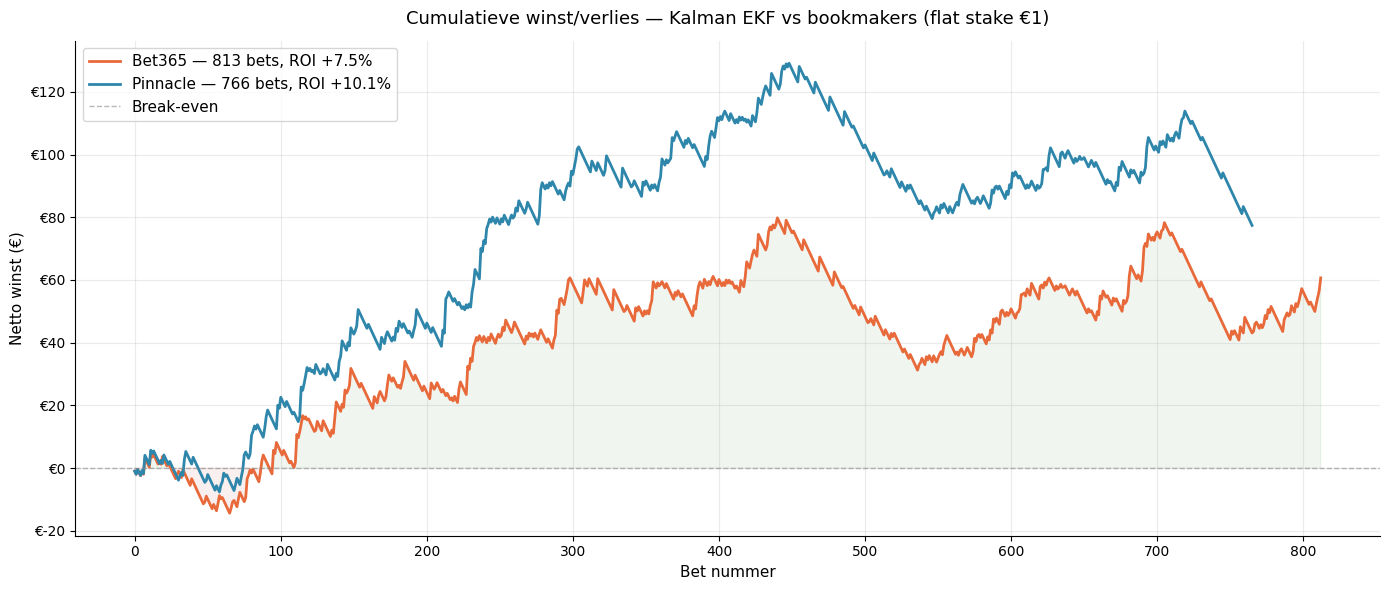

Plot 1 opgeslagen


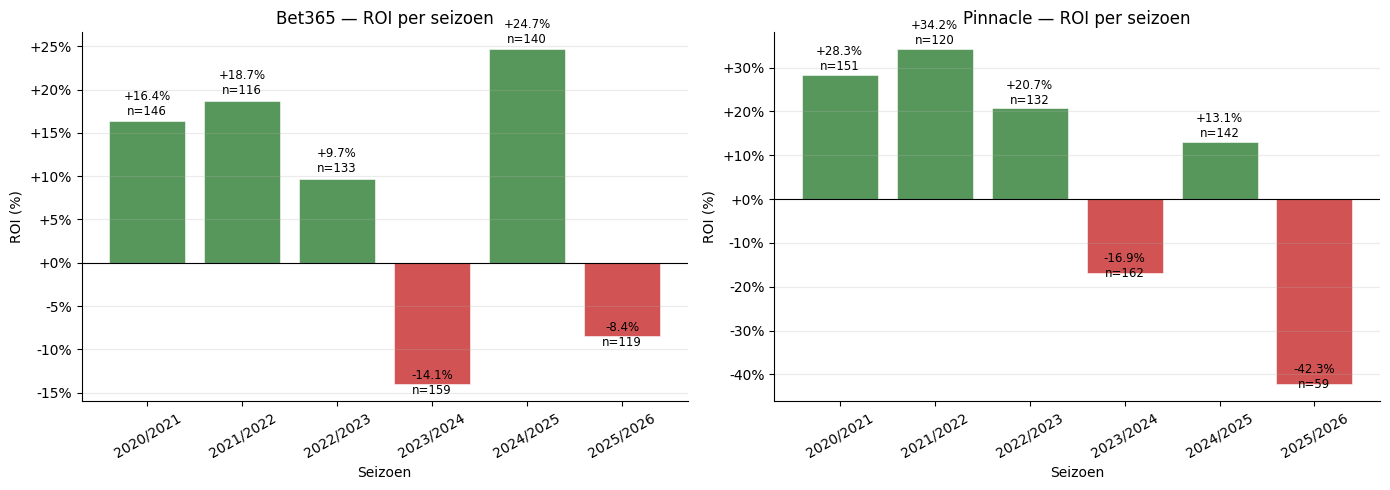

Plot 2 opgeslagen


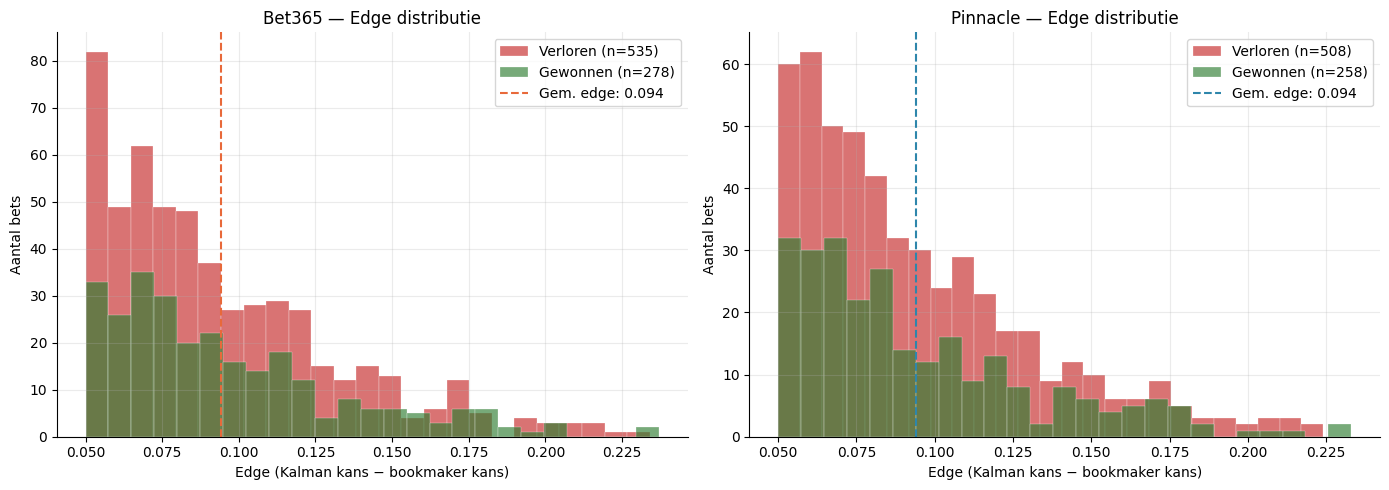

Plot 3 opgeslagen


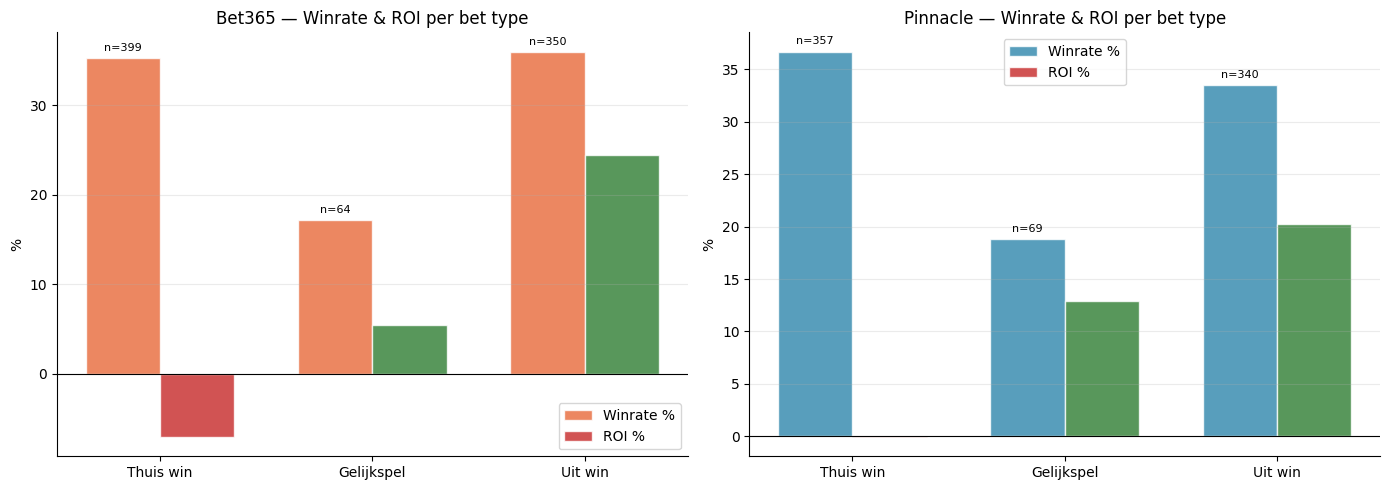

Plot 4 opgeslagen


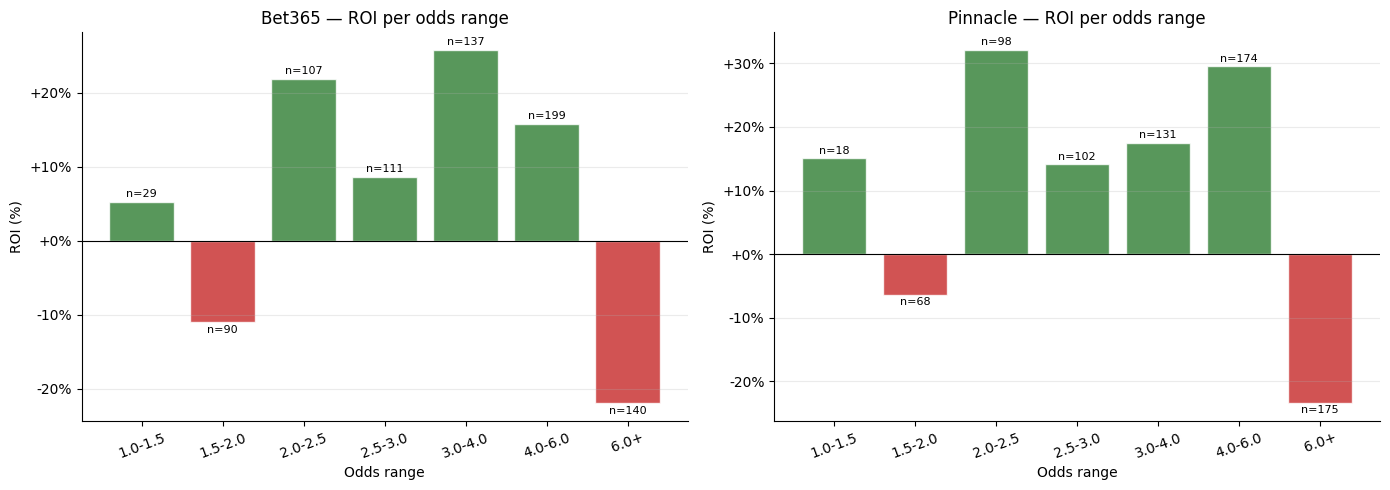

Plot 5 opgeslagen


In [ ]:
"""
Kalman Betting Resultaten — Visualisaties
==========================================
Input:  Kalman data/betting_results_b365_getuund.csv
        Kalman data/betting_results_pinn_getuund.csv
Output: 6 plots opgeslagen als PNG

Plots:
  1. Cumulatieve bankroll over tijd
  2. ROI per seizoen (bar chart)
  3. Edge distributie gewonnen vs verloren
  4. Winrate & ROI per bet type (H/D/A)
  5. ROI per odds range
  6. Rolling ROI (20-bet window)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\semwi\FPL-Core-Insights\data\Kalman data"

# ── Data laden ────────────────────────────────────────────────────────────────
b365 = pd.read_csv(f"{BASE_DIR}\\betting_results_b365_getuund.csv")
pinn = pd.read_csv(f"{BASE_DIR}\\betting_results_pinn_getuund.csv")
b365['date'] = pd.to_datetime(b365['date'])
pinn['date'] = pd.to_datetime(pinn['date'])

b365_roi = b365['profit'].sum() / len(b365) * 100
pinn_roi = pinn['profit'].sum() / len(pinn) * 100
print(f"Bet365:   {len(b365)} bets | Netto: €{b365['profit'].sum():.1f} | ROI: {b365_roi:+.1f}%")
print(f"Pinnacle: {len(pinn)} bets | Netto: €{pinn['profit'].sum():.1f} | ROI: {pinn_roi:+.1f}%")

# ── Stijl ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
C_B365 = '#E8693A'
C_PINN = '#2E86AB'
C_POS  = '#2E7D32'
C_NEG  = '#C62828'
C_BREAK= '#888888'

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Cumulatieve bankroll over tijd
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(b365)), b365['cumulative'], color=C_B365, linewidth=2.0,
        label=f'Bet365 — {len(b365)} bets, ROI {b365_roi:+.1f}%')
ax.plot(range(len(pinn)), pinn['cumulative'], color=C_PINN, linewidth=2.0,
        label=f'Pinnacle — {len(pinn)} bets, ROI {pinn_roi:+.1f}%')
ax.axhline(0, color=C_BREAK, linewidth=1.0, linestyle='--', alpha=0.6, label='Break-even')

ax.fill_between(range(len(b365)), b365['cumulative'], 0,
                where=b365['cumulative'] >= 0, alpha=0.07, color=C_POS)
ax.fill_between(range(len(b365)), b365['cumulative'], 0,
                where=b365['cumulative'] < 0, alpha=0.07, color=C_NEG)

ax.set_title('Cumulatieve winst/verlies — Kalman EKF vs bookmakers (flat stake €1)',
             fontsize=13, pad=12)
ax.set_xlabel('Bet nummer', fontsize=11)
ax.set_ylabel('Netto winst (€)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'€{x:.0f}'))
plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot1_cumulatief.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 opgeslagen")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — ROI per seizoen
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], b365, 'Bet365',   C_B365),
    (axes[1], pinn, 'Pinnacle', C_PINN),
]:
    if 'season' not in df.columns:
        ax.text(0.5, 0.5, 'Geen seizoen kolom', ha='center', va='center')
        continue

    seasons = sorted(df['season'].unique())
    rois    = [df[df['season']==s]['profit'].sum() / max(len(df[df['season']==s]),1) * 100
               for s in seasons]
    counts  = [len(df[df['season']==s]) for s in seasons]

    bars = ax.bar(seasons, rois,
                  color=[C_POS if r >= 0 else C_NEG for r in rois],
                  alpha=0.8, edgecolor='white', linewidth=0.5)

    for bar, roi, count in zip(bars, rois, counts):
        offset = 0.4 if roi >= 0 else -1.5
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                f'{roi:+.1f}%\nn={count}', ha='center', va='bottom', fontsize=8.5)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label} — ROI per seizoen', fontsize=12)
    ax.set_xlabel('Seizoen', fontsize=10)
    ax.set_ylabel('ROI (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.25, axis='y')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))

plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot2_roi_seizoen.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 opgeslagen")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Edge distributie gewonnen vs verloren
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], b365, 'Bet365',   C_B365),
    (axes[1], pinn, 'Pinnacle', C_PINN),
]:
    won  = df[df['won'] == True]['edge']
    lost = df[df['won'] == False]['edge']

    ax.hist(lost, bins=25, alpha=0.65, color=C_NEG, label=f'Verloren (n={len(lost)})',
            edgecolor='white', linewidth=0.3)
    ax.hist(won,  bins=25, alpha=0.65, color=C_POS, label=f'Gewonnen (n={len(won)})',
            edgecolor='white', linewidth=0.3)
    ax.axvline(df['edge'].mean(), color=color, linewidth=1.5, linestyle='--',
               label=f'Gem. edge: {df["edge"].mean():.3f}')

    ax.set_title(f'{label} — Edge distributie', fontsize=12)
    ax.set_xlabel('Edge (Kalman kans − bookmaker kans)', fontsize=10)
    ax.set_ylabel('Aantal bets', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot3_edge_distributie.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 opgeslagen")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Winrate & ROI per bet type (H/D/A)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], b365, 'Bet365',   C_B365),
    (axes[1], pinn, 'Pinnacle', C_PINN),
]:
    bet_types  = ['H', 'D', 'A']
    bet_labels = ['Thuis win', 'Gelijkspel', 'Uit win']
    winrates, rois, counts = [], [], []

    for bt in bet_types:
        sub = df[df['bet'] == bt]
        n   = len(sub)
        counts.append(n)
        winrates.append(sub['won'].mean() * 100 if n > 0 else 0)
        rois.append(sub['profit'].sum() / n * 100 if n > 0 else 0)

    x     = np.arange(len(bet_labels))
    width = 0.35
    bars1 = ax.bar(x - width/2, winrates, width, label='Winrate %',
                   color=color, alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + width/2, rois, width, label='ROI %',
                   color=[C_POS if r >= 0 else C_NEG for r in rois],
                   alpha=0.8, edgecolor='white')

    for bar, count in zip(bars1, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'n={count}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label} — Winrate & ROI per bet type', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(bet_labels, fontsize=10)
    ax.set_ylabel('%', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot4_winrate_bet_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 opgeslagen")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — ROI per odds range
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], b365, 'Bet365',   C_B365),
    (axes[1], pinn, 'Pinnacle', C_PINN),
]:
    bins   = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0, 20.0]
    lbls   = ['1.0-1.5','1.5-2.0','2.0-2.5','2.5-3.0','3.0-4.0','4.0-6.0','6.0+']
    df     = df.copy()
    df['odds_range'] = pd.cut(df['odds'], bins=bins, labels=lbls)

    rois, counts = [], []
    for lbl in lbls:
        sub = df[df['odds_range'] == lbl]
        n   = len(sub)
        counts.append(n)
        rois.append(sub['profit'].sum() / n * 100 if n > 0 else 0)

    bars = ax.bar(lbls, rois,
                  color=[C_POS if r >= 0 else C_NEG for r in rois],
                  alpha=0.8, edgecolor='white')

    for bar, count, roi in zip(bars, counts, rois):
        if count > 0:
            offset = 0.4 if roi >= 0 else -1.8
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                    f'n={count}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label} — ROI per odds range', fontsize=12)
    ax.set_xlabel('Odds range', fontsize=10)
    ax.set_ylabel('ROI (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, alpha=0.25, axis='y')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))

plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot5_roi_odds_range.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 opgeslagen")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — Rolling ROI (20-bet window)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
window = 20

for df, label, color in [(b365, 'Bet365', C_B365), (pinn, 'Pinnacle', C_PINN)]:
    rolling = df['profit'].rolling(window).mean() * 100
    ax.plot(range(len(df)), rolling, color=color, linewidth=1.8,
            label=f'{label} ({window}-bet rolling ROI)', alpha=0.9)

b365_rolling = b365['profit'].rolling(window).mean()
ax.fill_between(range(len(b365)), b365_rolling * 100, 0,
                where=b365_rolling >= 0, alpha=0.07, color=C_POS)
ax.fill_between(range(len(b365)), b365_rolling * 100, 0,
                where=b365_rolling < 0, alpha=0.07, color=C_NEG)

ax.axhline(0, color=C_BREAK, linewidth=1.0, linestyle='--', alpha=0.6, label='Break-even')
ax.set_title(f'Rolling ROI ({window}-bet window) — Kalman EKF model', fontsize=13)
ax.set_xlabel('Bet nummer', fontsize=11)
ax.set_ylabel('ROI (%)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))
plt.tight_layout()
plt.savefig(f"{BASE_DIR}\\plot6_rolling_roi.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 opgeslagen")

print(f"\nAlle 6 plots opgeslagen in: {BASE_DIR}")